In [114]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, label_binarize, LabelEncoder
from sklearn.model_selection import StratifiedKFold, cross_validate

from sklearn.base import clone
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, average_precision_score, f1_score, make_scorer, accuracy_score, recall_score
)
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from statsmodels.nonparametric.smoothers_lowess import lowess
from scipy.stats import kruskal
shark = pd.read_excel("shark.xlsx")

In [2]:
shark.head()
#Objective : Show which variable is most important fo people with high risk 

#Y = 3 categories : User Risk 
shark.shape[0]


1196

In [3]:
shark.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1196 entries, 0 to 1195
Data columns (total 60 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   UIN                          1196 non-null   int64  
 1   Incident.month               1196 non-null   int64  
 2   Incident.year                1196 non-null   int64  
 3   Victim.injury                1196 non-null   object 
 4   State                        1196 non-null   object 
 5   Location                     1193 non-null   object 
 6   Latitude                     1196 non-null   object 
 7   Longitude                    1196 non-null   float64
 8   Site.category                1196 non-null   object 
 9   Site.category.comment        23 non-null     object 
 10  Shark.common.name            1144 non-null   object 
 11  Shark.scientific.name        1144 non-null   object 
 12  Shark.identification.method  994 non-null    object 
 13  Shark.identificati

In [4]:
df_clean = shark.copy()
missing_ratio = df_clean.isna().mean()*100
missing_ratio.sort_values(ascending=False)

#dropping columns wiht missing rattio above 50
cols_to_drop = missing_ratio[missing_ratio>50.0].index
df_clean = df_clean.drop(columns=cols_to_drop)

print(f"Dropped: {len(cols_to_drop)} columns")
print (cols_to_drop.tolist())

dropped_cols_df = (
    missing_ratio[missing_ratio > 50.0]
    .sort_values(ascending=False)
    .to_frame(name="missing_pct")
)


dropped_cols_df
df_clean = df_clean.drop(columns="No.sharks")
df_clean= df_clean.drop(columns ="Injury.severity")
df_clean= df_clean.drop(columns ="Data.source")
df_clean= df_clean.drop(columns ="Reference")
df_clean.info()

Dropped: 37 columns
['Site.category.comment', 'Shark.identification.source', 'Shark.length.m', 'Basis.for.length', 'Provocative.act', 'Fish.speared?', 'Commercial.dive.activity', 'Object.of.bite', 'Present.at.time.of.bite', 'Direction.first.strike', 'Shark.captured', 'Victim.clothing', 'Clothing.coverage', 'Dominant.clothing.colour', 'Other.clothing.colour', 'Clothing.pattern', 'Fin.colour', 'Diversionary.action.taken', 'Diversionary.action.outcome', 'People <3m', 'People 3-15m', 'Time.of.incident', 'Depth.of.incident.m', 'Teeth.recovered', 'Time.in.water.min', 'Water.temperature.°C', 'Total.water.depth.m', 'Water.visability.m', 'Distance.to.shore.m', 'Spring.or.neap.tide', 'Tidal.cycle', 'Wind.condition', 'Weather.condition', 'Air.temperature.°C', 'Personal.protective.device', 'Deterrent.brand.and.type', 'Unnamed: 59']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1196 entries, 0 to 1195
Data columns (total 19 columns):
 #   Column                       Non-Null Count  Dtype  
---

Victim.injury
injured      723
fatal        250
uninjured    223
Name: count, dtype: int64


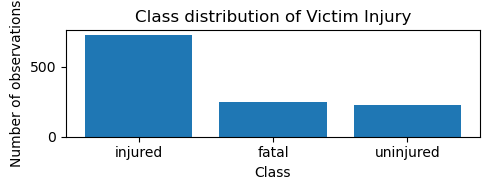

In [5]:
df_clean.head()
df_clean["Victim.injury"] = (
    df_clean["Victim.injury"]
    .astype(str)
    .str.strip()
    .str.lower()
)

#Class distribution plot
counts = df_clean["Victim.injury"].value_counts()
print(counts)
plt.figure(figsize=(5,2))
plt.bar(counts.index, counts.values)
plt.xlabel("Class")
plt.ylabel("Number of observations")
plt.title("Class distribution of Victim Injury")
plt.tight_layout()
plt.show()

In [6]:
df_clean["Victim.injury"].nunique()

3

In [7]:
#numerical values : Histogram
from sklearn.model_selection import train_test_split
X = df_clean.drop(columns="Victim.injury")
y = df_clean["Victim.injury"]
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

num = X_train.select_dtypes(exclude=["object"]).columns
cat = X_train.select_dtypes(include=["object"]).columns

print("Train shape:", X_train.shape, y_train.shape)
print("Validation shape:", X_val.shape, y_val.shape)

print("\nClass distribution (train):")
print(y_train.value_counts(normalize=True))

print("\nClass distribution (validation):")
print(y_val.value_counts(normalize=True))



Train shape: (956, 18) (956,)
Validation shape: (240, 18) (240,)

Class distribution (train):
Victim.injury
injured      0.598326
fatal        0.214435
uninjured    0.187238
Name: proportion, dtype: float64

Class distribution (validation):
Victim.injury
injured      0.629167
fatal        0.187500
uninjured    0.183333
Name: proportion, dtype: float64


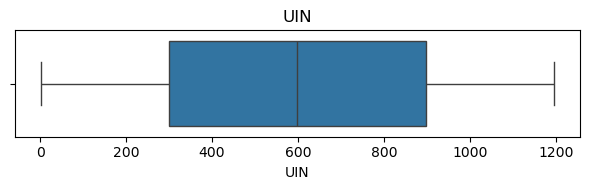

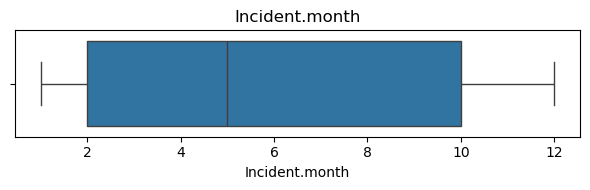

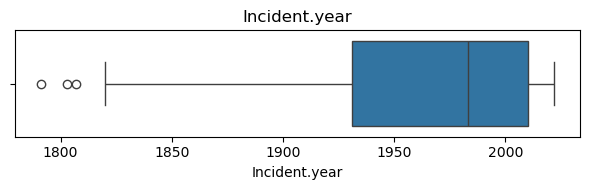

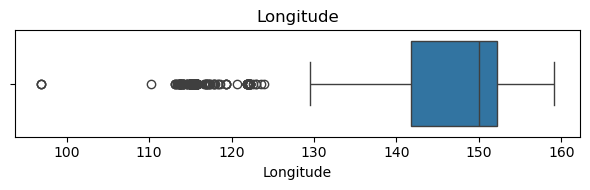

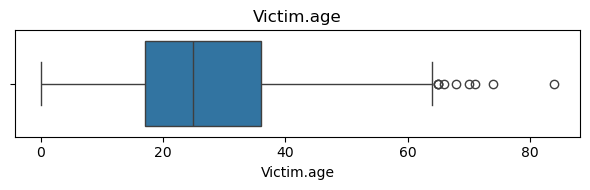

In [8]:
#boxplot to see outliers
import matplotlib.pyplot as plt
import seaborn as sns


for col in num:
    plt.figure(figsize=(6,2))
    
    sns.boxplot(x=df_clean[col])
    
    plt.title(f"{col}")
    plt.tight_layout()
    plt.show()

In [25]:
df_clean["State"].value_counts()

State
NSW    438
QLD    370
WA     199
SA      73
VIC     70
TAS     27
NT      19
Name: count, dtype: int64

In [10]:
#-------------------------------------------------feature engineering longitude and latitude with state--------------------------------------------
df_geo = df_clean.copy()

#latitude and longitude to numerical

df_geo["Latitude"] = pd.to_numeric(df_geo["Latitude"], errors="coerce")
df_geo["Longitude"] = pd.to_numeric(df_geo["Longitude"], errors="coerce")

GRID = 2.0  # degrees (try 0.5 or 1.0)

df_geo["lat_bin"] = (df_geo["Latitude"] // GRID) * GRID
df_geo["lon_bin"] = (df_geo["Longitude"] // GRID) * GRID

df_geo["geo_bin"] = (
    df_geo["lat_bin"].astype(str) + "_" +
    df_geo["lon_bin"].astype(str))
#WHAT DOES BIN ACTUALLY DO AND THIS WHOLE CODE IN GENERAL

unique_geo=df_geo["geo_bin"].nunique()
print(df_geo[["State", "geo_bin"]].head(10))
print("Geo Bins:", unique_geo)

  State      geo_bin
0   NSW  -34.0_150.0
1    WA  -26.0_112.0
2   NSW  -34.0_150.0
3   TAS  -44.0_146.0
4   NSW  -34.0_150.0
5   TAS  -44.0_146.0
6   NSW  -34.0_150.0
7   NSW  -34.0_150.0
8    SA  -36.0_138.0
9   QLD  -26.0_152.0
Geo Bins: 82


In [11]:
df_geo["Site.category"].value_counts().head(10)
df_geo["Site.category"] = (
    df_geo["Site.category"]
      .str.strip()
      .str.lower()
)
df_geo["Site.category"].value_counts()

Site.category
coastal              780
island open ocean    183
estuary/harbour      111
river                 93
ocean/pelagic         28
other: fish farm       1
Name: count, dtype: int64

In [12]:
df_geo["Shark.behaviour"].head(70)
df_geo["Shark.behaviour"].value_counts()

Shark.behaviour
bit victim on leg                                                                                                     241
bit victim on body                                                                                                     51
bit victim on foot                                                                                                     46
bit victim on arm                                                                                                      40
bit surfboard                                                                                                          34
                                                                                                                     ... 
witness saw him knocked off, but didn’t see the shark. shark took bite out of back of board - left tooth in board.      1
swam towards diver who poked shark with snare, shark bit snare and swam off                                             1
bit boar

In [13]:
#---------------------FEATURE ENGINEERING--------------------------------------------------------------------------
# Compiling patterns(faster + cleaner)
BITE_WORDS = re.compile(r"\b(bite|bit|bitten|biting)\b")
LEG_WORDS  = re.compile(r"\b(leg|legs|lower\s*leg|upper\s*leg|calf|thigh|knee|ankle|shin)\b")
ARM_WORDS  = re.compile(r"\b(arm|arms|hand|hands|wrist|forearm|elbow|finger|fingers)\b")
FOOT_WORDS = re.compile(r"\b(foot|feet|toe|toes|heel)\b")
BODY_WORDS = re.compile(r"\b(body|torso|chest|abdomen|stomach|back|shoulder|neck|head)\b")

ATTACK_WORDS      = re.compile(r"\b(attacked|attack|struck)\b")
AGGRESSIVE_WORDS  = re.compile(r"\b(aggressive|rushed)\b")
GRAZE_WORDS       = re.compile(r"\b(grazed)\b")
BUMP_WORDS        = re.compile(r"\b(bumped|knocked)\b")
APPROACH_WORDS    = re.compile(r"\b(swam\s+towards|circled)\b")

def categorize_behaviour(text):
    if pd.isna(text) or str(text).strip() == "":
        return "unknown"
    
    t = str(text).lower()

    # highest severity first
    if ATTACK_WORDS.search(t):
        return "attack/strike"
    if AGGRESSIVE_WORDS.search(t):
        return "aggressive/threat"
    if GRAZE_WORDS.search(t):
        return "graze/minor_contact"
    if BUMP_WORDS.search(t):
        return "bump/contact"
    if APPROACH_WORDS.search(t):
        return "approach/interest"

    # bite-related (fallback)
    has_bite = bool(BITE_WORDS.search(t))
    if not has_bite:
        return "other"

    # prioritize specific locations
    if LEG_WORDS.search(t):
        return "bit legs"
    if ARM_WORDS.search(t):
        return "bit arms"
    if FOOT_WORDS.search(t):
        return "bit feet"
    if BODY_WORDS.search(t):
        return "bit body"

    return "bit other"  # bite mentioned but no clear body part

df_geo["bitvsother"] = df_geo["Shark.behaviour"].apply(categorize_behaviour)
df_geo["bitvsother"].value_counts(dropna=False)


bitvsother
bit legs               356
unknown                216
bit other              185
bit body               103
bit arms               100
bit feet                69
bump/contact            56
approach/interest       41
other                   39
graze/minor_contact     15
aggressive/threat        9
attack/strike            7
Name: count, dtype: int64

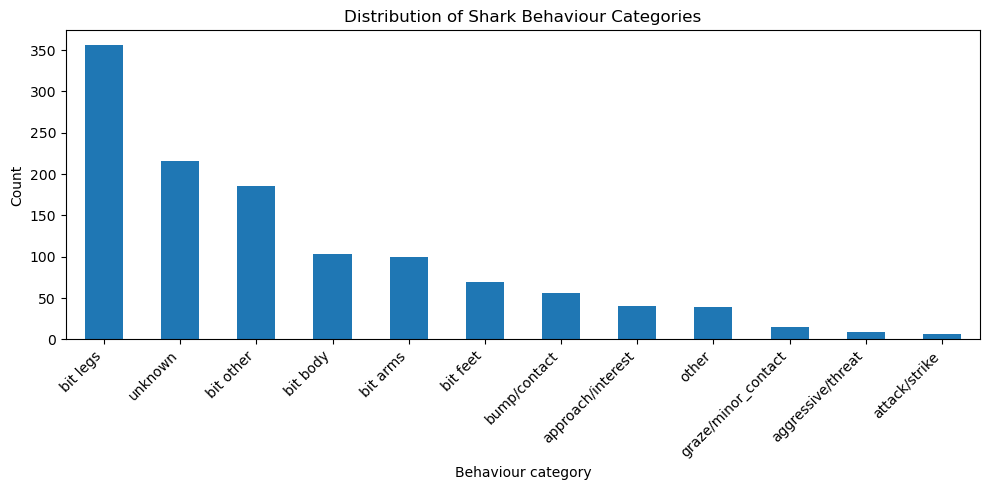

In [14]:
#count categories and plot graph of Shark Behaviour
counts = df_geo["bitvsother"].value_counts(dropna=False)

plt.figure(figsize=(10, 5))
counts.plot(kind="bar")
plt.xlabel("Behaviour category")
plt.ylabel("Count")
plt.title("Distribution of Shark Behaviour Categories")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [15]:
df_geo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1196 entries, 0 to 1195
Data columns (total 23 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   UIN                          1196 non-null   int64  
 1   Incident.month               1196 non-null   int64  
 2   Incident.year                1196 non-null   int64  
 3   Victim.injury                1196 non-null   object 
 4   State                        1196 non-null   object 
 5   Location                     1193 non-null   object 
 6   Latitude                     1190 non-null   float64
 7   Longitude                    1196 non-null   float64
 8   Site.category                1196 non-null   object 
 9   Shark.common.name            1144 non-null   object 
 10  Shark.scientific.name        1144 non-null   object 
 11  Shark.identification.method  994 non-null    object 
 12  Provoked/unprovoked          1192 non-null   object 
 13  Victim.activity   

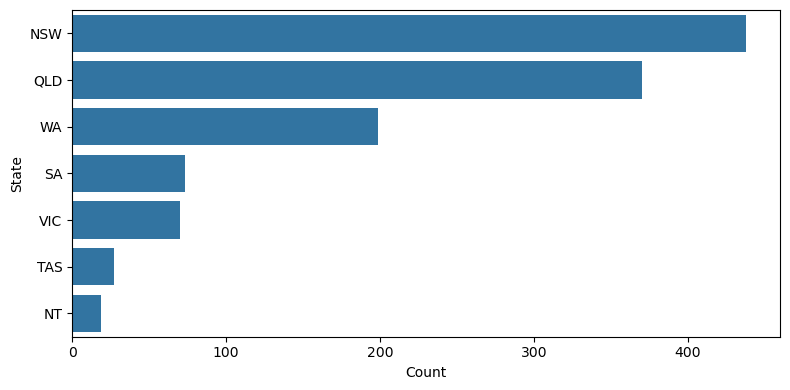

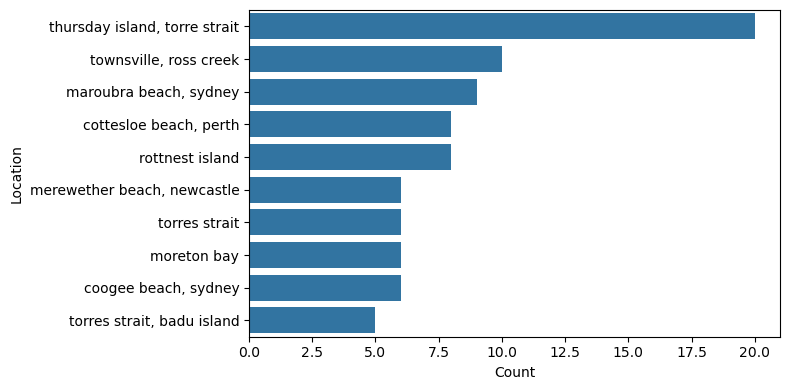

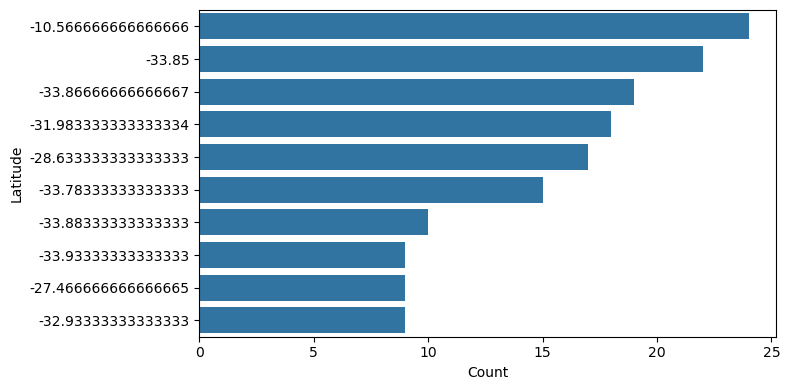

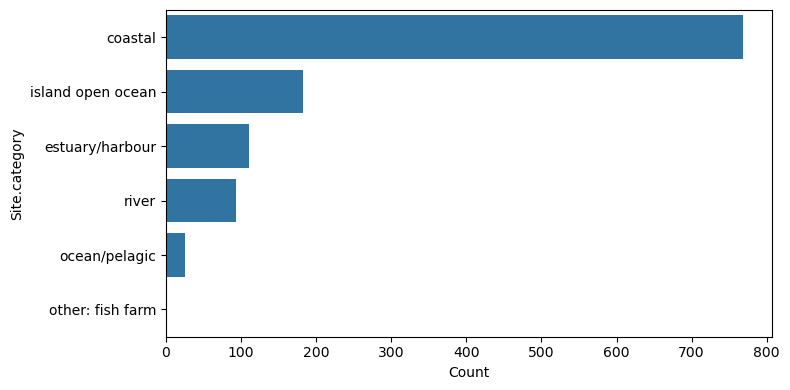

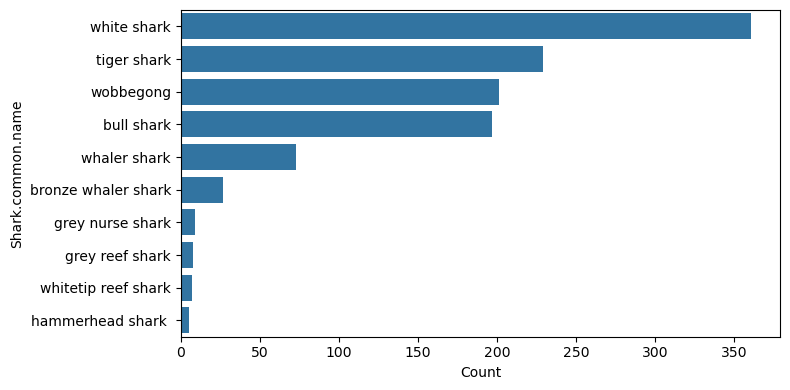

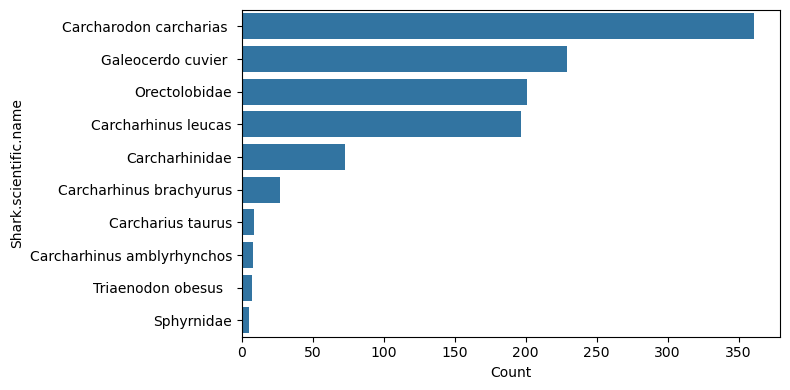

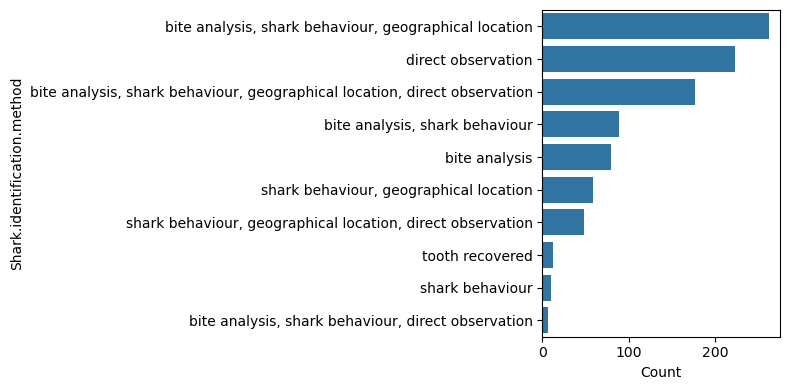

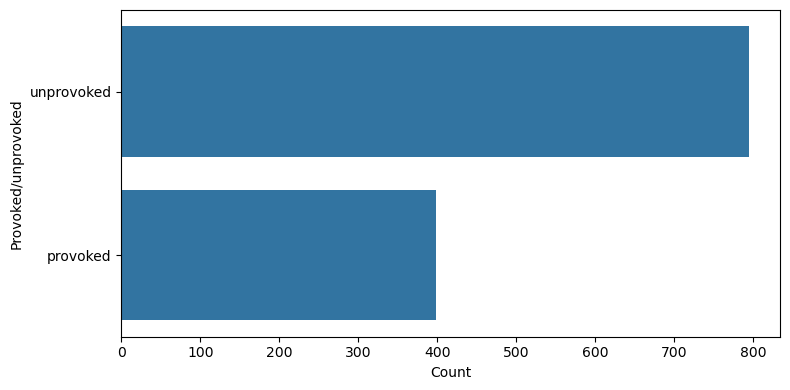

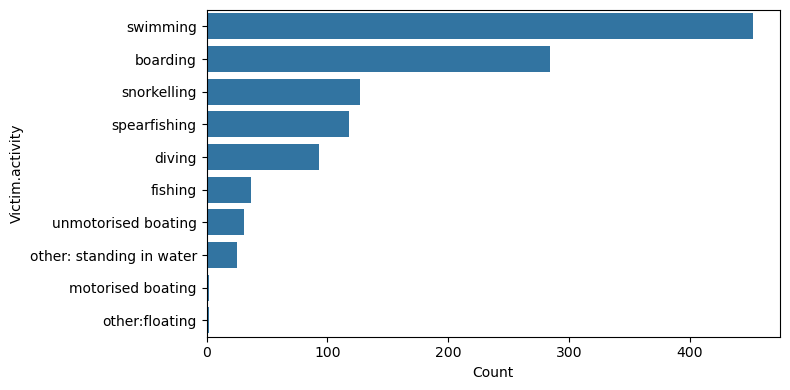

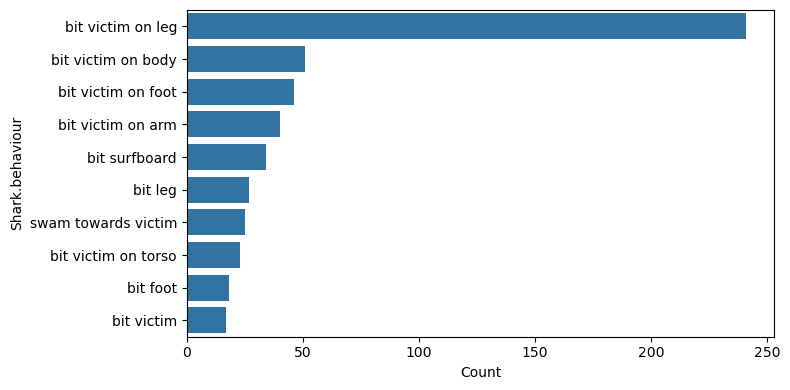

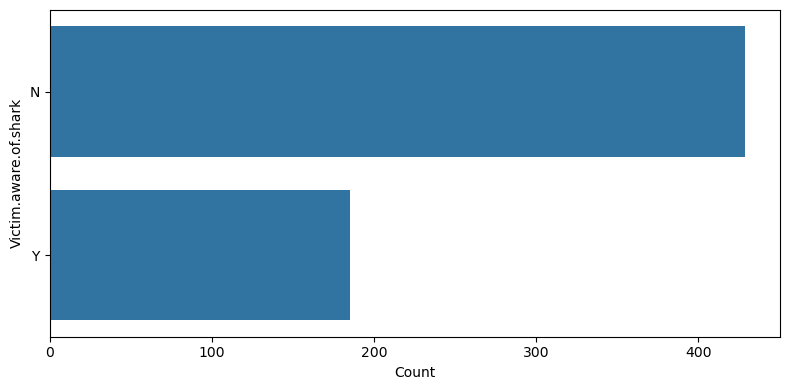

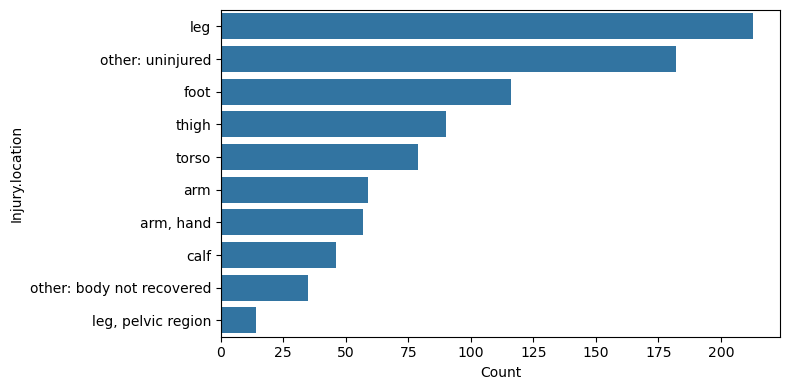

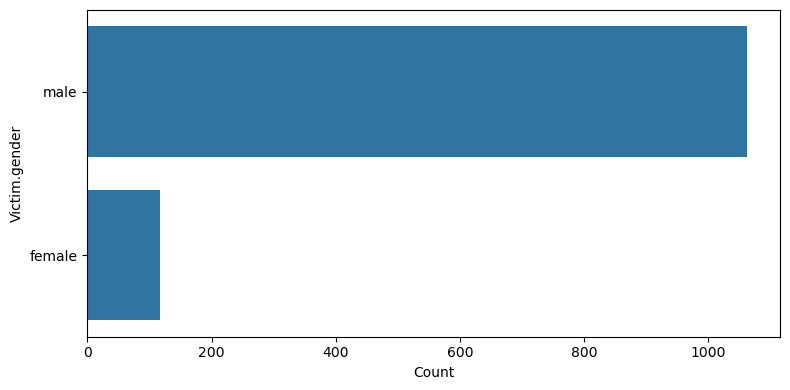

In [16]:
#-----------------------------------------PLOTS--------------------------------------------------------------------------
for col in cat :
    plt.figure(figsize=(8,4))
    order = df_geo[col].value_counts().head(10).index
    sns.countplot(
        data=df_clean,
        y=col,
        order=order
    )
    plt.xlabel("Count")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()
    

In [17]:
df_clean.shape

(1196, 19)

In [108]:
#keeping only certain features
data1 = df_geo.copy()
drop_cols = ["Latitude", "Longitude", "lat_bin", "lon_bin","Victim.injury","Shark.identification.method","UIN","Shark.scientific.name","Victim.aware.of.shark"]
X= data1.drop(columns=drop_cols)
y=data1["Victim.injury"]
counts = df_clean["Victim.injury"].value_counts()

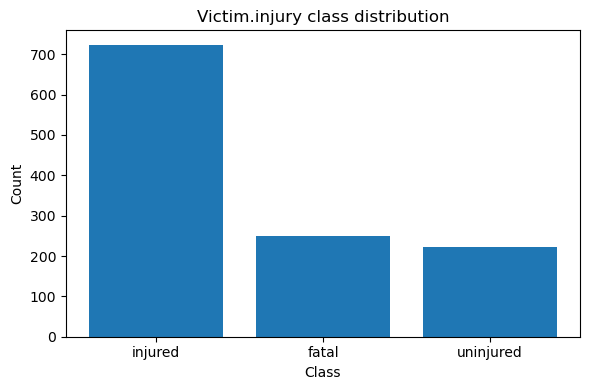

                                 Feature    Dtype  Missing (%)
Victim.age                    Victim.age  float64        41.56
Shark.behaviour          Shark.behaviour   object        18.06
Injury.location          Injury.location   object        10.87
Shark.common.name      Shark.common.name   object         4.35
Victim.activity          Victim.activity   object         2.09
Victim.gender              Victim.gender   object         1.42
Provoked/unprovoked  Provoked/unprovoked   object         0.33
Location                        Location   object         0.25
Incident.month            Incident.month    int64         0.00
Incident.year              Incident.year    int64         0.00
Site.category              Site.category   object         0.00
State                              State   object         0.00
geo_bin                          geo_bin   object         0.00
bitvsother                    bitvsother   object         0.00


In [105]:
#-------MULTICLASS MODEL : Encoding Labels---------------------------------------------
le = LabelEncoder()
data1["injury_class"] = le.fit_transform(data1["Victim.injury"])
dict(zip(le.classes_, le.transform(le.classes_)))


# -----------------------------
#----------DROPPING COLUMNS AND CLASS DISTRIBUTION PLOT------------------------------
# -----------------------------
data1 = df_geo.copy()

drop_cols = [
    "Latitude", "Longitude", "lat_bin", "lon_bin",
    "Victim.injury", "Shark.identification.method",
    "UIN", "Shark.scientific.name","Victim.aware.of.shark"
]

X = data1.drop(columns=drop_cols, errors="ignore")
y = data1["Victim.injury"]


counts = y.value_counts()

plt.figure(figsize=(6, 4))
plt.bar(counts.index.astype(str), counts.values)
plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Victim.injury class distribution")
plt.tight_layout()
plt.show()

# Optional: quick feature summary
summary_table = pd.DataFrame({
    "Feature": X.columns,
    "Dtype": X.dtypes.astype(str),
    "Missing (%)": (X.isna().mean() * 100).round(2)
}).sort_values("Missing (%)", ascending=False)

print(summary_table)

In [109]:
#-------------------------------TRAIN TEST VALIDATION SPLIT-------------------------------------------
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# Column lists--------------------
num_cols = X_train.select_dtypes(exclude=["object"]).columns
cat_cols = X_train.select_dtypes(include=["object"]).columns


#-----------------------------Preprocessing pipelines-----------------
num_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
    ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols)
])


#----------------------------- Multiclass model (Logistic Regression)-----------------------------

model1 = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("clf", LogisticRegression(
        solver="lbfgs",
        class_weight="balanced",
        max_iter=3000,
        random_state=42
    ))
])

# ----------------------------- FIT And PREDICT ---------------------------------------------------------
model1.fit(X_train, y_train)
y_pred = model1.predict(X_val)
y_proba = model1.predict_proba(X_val)  # shape: (n_samples, n_classes)


print("Confusion Matrix:\n", confusion_matrix(y_val, y_pred))
print("\nClassification Report:\n", classification_report(y_val, y_pred))
print("\ny_val distribution:\n", pd.Series(y_val).value_counts())
print("\ny_pred distribution:\n", pd.Series(y_pred).value_counts())

# -----------------------------
# 9) Correct multiclass ROC-AUC + AUC-PR
#    IMPORTANT: class order must match y_proba columns!
# -----------------------------
clf = model1.named_steps["clf"]
classes = clf.classes_   # this is the correct order for y_proba columns

# Binarize y_val using the SAME class order
y_val_bin = label_binarize(y_val, classes=classes)

# -----------------------------ROC-AUC-----------------------------
roc_auc_macro_ovr = roc_auc_score(
    y_val_bin,
    y_proba,
    multi_class="ovr",
    average="macro"
)

ap_macro = average_precision_score(y_val_bin, y_proba, average="macro")
ap_weighted = average_precision_score(y_val_bin, y_proba, average="weighted")

print("\nModel class order:", classes)
print("ROC-AUC (macro, OVR):", roc_auc_macro_ovr)
print("AUC-PR (macro):", ap_macro)
print("AUC-PR (weighted):", ap_weighted)


Confusion Matrix:
 [[ 32  13   5]
 [ 31 110   4]
 [  0   1  44]]

Classification Report:
               precision    recall  f1-score   support

       fatal       0.51      0.64      0.57        50
     injured       0.89      0.76      0.82       145
   uninjured       0.83      0.98      0.90        45

    accuracy                           0.78       240
   macro avg       0.74      0.79      0.76       240
weighted avg       0.80      0.78      0.78       240


y_val distribution:
 Victim.injury
injured      145
fatal         50
uninjured     45
Name: count, dtype: int64

y_pred distribution:
 injured      124
fatal         63
uninjured     53
Name: count, dtype: int64

Model class order: ['fatal' 'injured' 'uninjured']
ROC-AUC (macro, OVR): 0.9194101822982645
AUC-PR (macro): 0.845312608682882
AUC-PR (weighted): 0.8784072022308199


In [23]:

def roc_auc_macro_ovr(estimator, X, y):
    proba = estimator.predict_proba(X)
    classes = estimator.named_steps["clf"].classes_
    y_bin = label_binarize(y, classes=classes)
    return roc_auc_score(y_bin, proba, multi_class="ovr", average="macro")

def auprc_macro(estimator, X, y):
    proba = estimator.predict_proba(X)
    classes = estimator.named_steps["clf"].classes_
    y_bin = label_binarize(y, classes=classes)
    return average_precision_score(y_bin, proba, average="macro")

# OVERWRITE scoring completely (do not reuse old one)
scoring = {
    "f1_macro": make_scorer(f1_score, average="macro", zero_division=0),
    "roc_auc_ovr_macro": roc_auc_macro_ovr,
    "auprc_macro": auprc_macro,
}

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)  

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_res_log = cross_validate(
    model1,
    X_train,
    y_train_enc,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    error_score="raise"
)

for k, v in cv_res_log.items():
    if k.startswith("test_"):
        print(f"{k}: mean={v.mean():.4f}, std={v.std():.4f}")


test_f1_macro: mean=0.8132, std=0.0340
test_roc_auc_ovr_macro: mean=0.9391, std=0.0073
test_auprc_macro: mean=0.8872, std=0.0176


In [ ]:
import numpy as np
print("Unique classes in y_train:", np.unique(y_train))
print("Unique classes in y_val:", np.unique(y_val))

In [110]:
#-------------------------------FEATURE IMPORTANCE----------------------------------------
feature_names = model1[:-1].get_feature_names_out()
lr = model1.named_steps["clf"]   # change if your step name differs

coef_df = pd.DataFrame(lr.coef_, columns=feature_names, index=lr.classes_).T
coef_df["overall_importance"] = np.linalg.norm(lr.coef_, axis=0)
coef_df = coef_df.sort_values("overall_importance", ascending=False)
coef_df.head(20)


,fatal,injured,uninjured,overall_importance
cat__Injury.location_other: uninjured,-1.811878,-2.542095,4.353973,5.357446
cat__Injury.location_other: body not recovered,1.849522,-1.555979,-0.293543,2.434742
cat__Injury.location_Unknown,-0.516160,-1.287612,1.803773,2.275514
cat__Shark.common.name_wobbegong,-1.308287,1.222930,0.085357,1.792891
cat__Injury.location_foot,-1.001429,1.398817,-0.397388,1.765635
cat__Shark.common.name_tiger shark,0.929110,-1.085459,0.156349,1.437328
cat__Shark.behaviour_bit victim on body,1.050227,-0.802769,-0.247458,1.344861
"cat__Injury.location_arm, hand",-0.758299,1.059282,-0.300983,1.337044
cat__Shark.common.name_white shark,1.014347,-0.767006,-0.247341,1.295522
"cat__Location_broadhurst reef, townsville",-0.700003,-0.266224,0.966227,1.222487


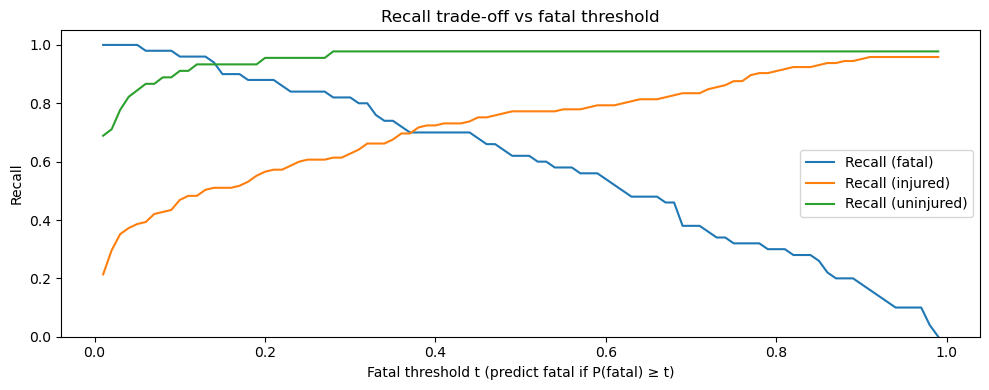

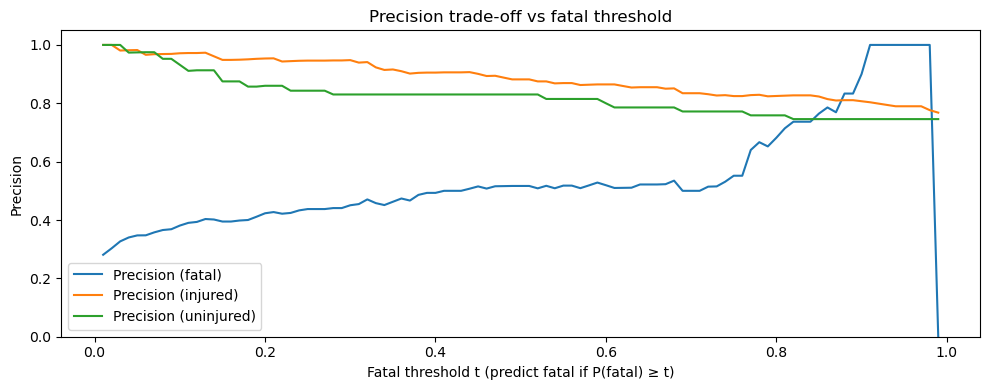

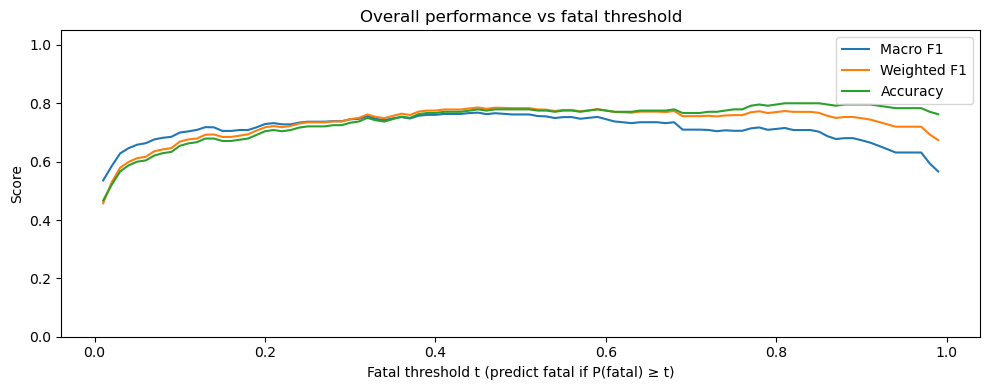

In [33]:

# ------------------------------------------------MODEL 1 : LOGISTIS REGRESSION /Base Model -------------------------------------------------
proba = model1.predict_proba(X_val)
classes = model1.classes_
classes_list = list(classes)

fatal_idx = classes_list.index("fatal")

# best non-fatal class for each row (injured vs uninjured)
proba_nonfatal = proba.copy()
proba_nonfatal[:, fatal_idx] = -1
best_nonfatal = classes[proba_nonfatal.argmax(axis=1)]

thresholds = np.linspace(0.01, 0.99, 99)

# store metrics
fatal_prec, fatal_rec, fatal_f1 = [], [], []
inj_prec, inj_rec, inj_f1 = [], [], []
uninj_prec, uninj_rec, uninj_f1 = [], [], []
macro_f1s, weighted_f1s, accs = [], [], []

for t in thresholds:
    y_pred_thr = np.where(proba[:, fatal_idx] >= t, "fatal", best_nonfatal)

    # per-class metrics (aligned to your class order)
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_val, y_pred_thr, labels=classes, zero_division=0
    )

    # map indices
    i_fatal = classes_list.index("fatal")
    i_inj = classes_list.index("injured")
    i_uninj = classes_list.index("uninjured")

    fatal_prec.append(prec[i_fatal]); fatal_rec.append(rec[i_fatal]); fatal_f1.append(f1[i_fatal])
    inj_prec.append(prec[i_inj]);     inj_rec.append(rec[i_inj]);     inj_f1.append(f1[i_inj])
    uninj_prec.append(prec[i_uninj]); uninj_rec.append(rec[i_uninj]); uninj_f1.append(f1[i_uninj])

    macro_f1s.append(f1_score(y_val, y_pred_thr, average="macro"))
    weighted_f1s.append(f1_score(y_val, y_pred_thr, average="weighted"))
    accs.append(accuracy_score(y_val, y_pred_thr))
# ------------------------------------------------PLOTS-------------------------------------------------
# --- Plot 1: Recall trade-off curves ---
plt.figure(figsize=(10,4))
plt.plot(thresholds, fatal_rec, label="Recall (fatal)")
plt.plot(thresholds, inj_rec, label="Recall (injured)")
plt.plot(thresholds, uninj_rec, label="Recall (uninjured)")
plt.xlabel("Fatal threshold t (predict fatal if P(fatal) ≥ t)")
plt.ylabel("Recall")
plt.title("Recall trade-off vs fatal threshold")
plt.ylim(0, 1.05)
plt.legend()
plt.tight_layout()
plt.show()

# --- Plot 2: Precision trade-off curves ---
plt.figure(figsize=(10,4))
plt.plot(thresholds, fatal_prec, label="Precision (fatal)")
plt.plot(thresholds, inj_prec, label="Precision (injured)")
plt.plot(thresholds, uninj_prec, label="Precision (uninjured)")
plt.xlabel("Fatal threshold t (predict fatal if P(fatal) ≥ t)")
plt.ylabel("Precision")
plt.title("Precision trade-off vs fatal threshold")
plt.ylim(0, 1.05)
plt.legend()
plt.tight_layout()
plt.show()

# --- Plot 3: Overall score curves (macro vs weighted vs accuracy) ---
plt.figure(figsize=(10,4))
plt.plot(thresholds, macro_f1s, label="Macro F1")
plt.plot(thresholds, weighted_f1s, label="Weighted F1")
plt.plot(thresholds, accs, label="Accuracy")
plt.xlabel("Fatal threshold t (predict fatal if P(fatal) ≥ t)")
plt.ylabel("Score")
plt.title("Overall performance vs fatal threshold")
plt.ylim(0, 1.05)
plt.legend()
plt.tight_layout()
plt.show()


In [35]:
#-------------------------------------MODEL 2 (LOGISTIC REGRESSION) with TUNED THRESHOLD----------------------------
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, precision_score

proba = model1.predict_proba(X_val)
classes = model1.classes_

fatal_idx = list(classes).index("fatal")
threshold = 0.25

# best class overall
best_class = classes[proba.argmax(axis=1)]

# best non-fatal class (injured vs uninjured)
proba_nonfatal = proba.copy()
proba_nonfatal[:, fatal_idx] = -1
best_nonfatal = classes[proba_nonfatal.argmax(axis=1)]

# apply fatal threshold
y_pred_thr = np.where(proba[:, fatal_idx] >= threshold, "fatal", best_nonfatal)

print("Confusion Matrix (thr=0.25):\n",
      confusion_matrix(y_val, y_pred_thr, labels=classes))

print("\nClassification Report (thr=0.25):\n",
      classification_report(y_val, y_pred_thr, zero_division=0))

print("Accuracy:", accuracy_score(y_val, y_pred_thr))
print("F1 macro:", f1_score(y_val, y_pred_thr, average="macro", zero_division=0))
print("F1 weighted:", f1_score(y_val, y_pred_thr, average="weighted", zero_division=0))



Confusion Matrix (thr=0.25):
 [[42  4  4]
 [53 88  4]
 [ 1  1 43]]

Classification Report (thr=0.25):
               precision    recall  f1-score   support

       fatal       0.44      0.84      0.58        50
     injured       0.95      0.61      0.74       145
   uninjured       0.84      0.96      0.90        45

    accuracy                           0.72       240
   macro avg       0.74      0.80      0.74       240
weighted avg       0.82      0.72      0.73       240

Accuracy: 0.7208333333333333
F1 macro: 0.7368905324686953
F1 weighted: 0.734610475183224


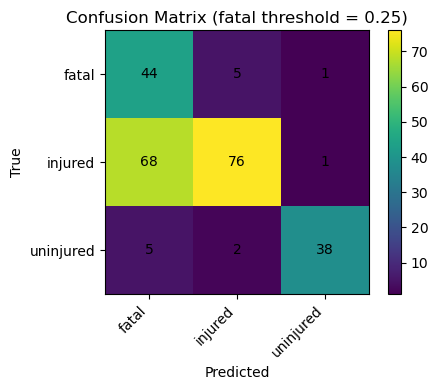

In [47]:
#----------------------------CONFUSION MATRIX-------------------------------
cm = confusion_matrix(y_val, y_pred_thr, labels=classes)

plt.figure(figsize=(5, 4))
plt.imshow(cm)
plt.colorbar()
plt.xticks(range(len(classes)), classes, rotation=45, ha="right")
plt.yticks(range(len(classes)), classes)

for i in range(len(classes)):
    for j in range(len(classes)):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (fatal threshold = 0.25)")
plt.tight_layout()
plt.show()



In [94]:
#Confirming 48% Missing
df_check["aware_missing"] = df_check["Victim.aware.of.shark"].isna()

df_check.groupby("aware_missing")["Incident.year"].median()

df_check["aware_missing"] = df_check["Victim.aware.of.shark"].isna().astype(int)
pd.crosstab(df_check["aware_missing"], df_check["Victim.injury"], normalize="index")



Victim.injury,fatal,injured,uninjured
aware_missing,,,
0,0.244300,0.576547,0.179153
1,0.171821,0.634021,0.194158


In [104]:
#MODEL 2 (WITHOUT Victim.aware.of.shark) + Stratified K Fold
drop_aware = FunctionTransformer(
    lambda X: X.drop(columns=["Victim.aware.of.shark"], errors="ignore")
)

model_no_aware_template = Pipeline(steps=[
    ("drop_col", drop_aware),
    ("preprocessor", clone(model1.named_steps["preprocessor"])),
    ("clf", clone(model1.named_steps["clf"]))
])

# 2) Stratified K-Fold evaluation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

classes_all = np.unique(y_train)   # or np.unique(y) if you have full y
y_oof_pred = np.empty_like(y_train, dtype=object)
y_oof_proba = None  # will allocate after first fold once we know n_classes

fold_rows = []

for fold, (tr_idx, te_idx) in enumerate(skf.split(X_train, y_train), start=1):
    X_tr, X_te = X_train.iloc[tr_idx], X_train.iloc[te_idx]
    y_tr, y_te = y_train.iloc[tr_idx], y_train.iloc[te_idx]

    model = clone(model_no_aware_template)
    model.fit(X_tr, y_tr)

    pred = model.predict(X_te)
    proba = model.predict_proba(X_te)

    # allocate oof proba matrix once
    if y_oof_proba is None:
        y_oof_proba = np.zeros((len(y_train), proba.shape[1]), dtype=float)

    y_oof_pred[te_idx] = pred
    y_oof_proba[te_idx, :] = proba

    # fold metrics
    y_te_bin = label_binarize(y_te, classes=classes_all)

    roc = roc_auc_score(y_te_bin, proba, multi_class="ovr", average="macro")
    ap_macro = average_precision_score(y_te_bin, proba, average="macro")
    ap_weighted = average_precision_score(y_te_bin, proba, average="weighted")
    f1m = f1_score(y_te, pred, average="macro", zero_division=0)

    fold_rows.append({
        "fold": fold,
        "ROC_AUC_macro_ovr": roc,
        "AUC_PR_macro": ap_macro,
        "AUC_PR_weighted": ap_weighted,
        "F1_macro": f1m
    })

# 3) Overall (OOF) results
print("=== SKF (OOF) WITHOUT Victim.aware.of.shark ===")
print("Confusion Matrix:\n", confusion_matrix(y_train, y_oof_pred, labels=classes_all))
print("\nClassification Report:\n", classification_report(y_train, y_oof_pred, zero_division=0))

y_train_bin = label_binarize(y_train, classes=classes_all)
roc_oof = roc_auc_score(y_train_bin, y_oof_proba, multi_class="ovr", average="macro")
ap_macro_oof = average_precision_score(y_train_bin, y_oof_proba, average="macro")
ap_weighted_oof = average_precision_score(y_train_bin, y_oof_proba, average="weighted")
f1_macro_oof = f1_score(y_train, y_oof_pred, average="macro", zero_division=0)

print("Class order:", classes_all)
print("ROC-AUC (macro, OVR) OOF:", roc_oof)
print("AUC-PR (macro) OOF:", ap_macro_oof)
print("AUC-PR (weighted) OOF:", ap_weighted_oof)
print("F1 macro OOF:", f1_macro_oof)

# 4) Fold-by-fold table (nice to see stability)
df_folds = pd.DataFrame(fold_rows)
print("\nPer-fold metrics:")
print(df_folds)
print("\nMean ± Std:")
print(df_folds.drop(columns=["fold"]).agg(["mean", "std"]))


=== SKF (OOF) WITHOUT Victim.aware.of.shark ===
Confusion Matrix:
 [[151  45   4]
 [101 470   8]
 [  3   4 171]]

Classification Report:
               precision    recall  f1-score   support

       fatal       0.59      0.76      0.66       200
     injured       0.91      0.81      0.86       579
   uninjured       0.93      0.96      0.95       178

    accuracy                           0.83       957
   macro avg       0.81      0.84      0.82       957
weighted avg       0.85      0.83      0.83       957

Class order: ['fatal' 'injured' 'uninjured']
ROC-AUC (macro, OVR) OOF: 0.9393181953182173
AUC-PR (macro) OOF: 0.8798833181927193
AUC-PR (weighted) OOF: 0.9039210302318146
F1 macro OOF: 0.8224022294772942

Per-fold metrics:
   fold  ROC_AUC_macro_ovr  AUC_PR_macro  AUC_PR_weighted  F1_macro
0     1           0.947534      0.892200         0.916370  0.824359
1     2           0.960286      0.917344         0.934200  0.861996
2     3           0.922020      0.859011         0.882

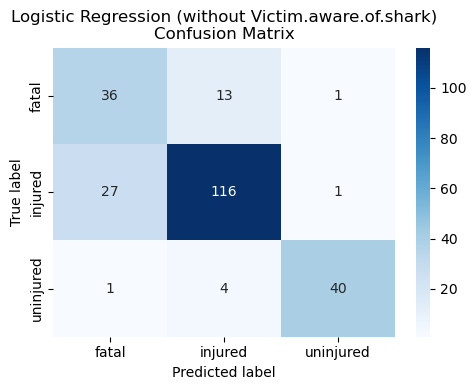

In [96]:
#----------------CONFUSION MATRIX---------------------------
cm = confusion_matrix(y_val, y_pred2, labels=classes2)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=classes2,
    yticklabels=classes2
)

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Logistic Regression (without Victim.aware.of.shark)\nConfusion Matrix")
plt.tight_layout()
plt.show()


In [49]:
#--------------------------------MODEL 3 : XGBoost with Sample Weight--------------------------------------------
#SAMPLE WEIGHT FOR XGBoost

from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train_enc)
weights = compute_class_weight("balanced", classes=classes, y=y_train_enc)
class_weight = {
    0: 1.5,  # fatal
    1: 1.7,  # injured
    2: 0.5  # uninjured
}
sample_weight = y_train.map(class_weight)




In [50]:
import numpy as np
import pandas as pd

from xgboost import XGBClassifier

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    average_precision_score,
    precision_recall_curve,
    classification_report,
    confusion_matrix
)

neg = (y_train == 0).sum()
pos = (y_train == 1).sum()

pos_weight = neg / pos if pos > 0 else 1.0

# 1) encode y
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)   # e.g. fatal=0, injured=1, uninjured=2
y_val_enc   = le.transform(y_val)


xgb = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1 
)

model2= Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("xgb", xgb)
])
sample_weight = np.array([class_weight[y] for y in y_train_enc])

model2.fit(
    X_train,
    y_train_enc,
    xgb__sample_weight=sample_weight
)

y_pred_enc = model2.predict(X_val)
xgb_y_pred = le.inverse_transform(y_pred_enc)

proba = model2.predict_proba(X_val)

from sklearn.metrics import confusion_matrix, classification_report

print("XGB PREDICTION ONLY WITH SAMPLE WEIGHT")
f1_macro_plain = f1_score(y_val, xgb_y_pred, average="macro", zero_division=0)
print("F1 macro (plain predict):", f1_macro_plain)

print(confusion_matrix(y_val, xgb_y_pred, labels=le.classes_))
print(classification_report(y_val, xgb_y_pred))


import numpy as np

classes = le.classes_
fatal_idx = list(classes).index("fatal")

threshold = 0.07

# best non-fatal
proba_nonfatal = proba.copy()
proba_nonfatal[:, fatal_idx] = -1
best_nonfatal = classes[proba_nonfatal.argmax(axis=1)]

# apply threshold
y_pred_xgbthr = np.where(proba[:, fatal_idx] >= threshold, "fatal", best_nonfatal)

print("XGB PREDICTION SAMPLE WEIGHT AND THRESHOLD")
from sklearn.metrics import f1_score

f1_macro = f1_score(y_val, y_pred_xgbthr, average="macro", zero_division=0)
f1_weighted = f1_score(y_val, y_pred_xgbthr, average="weighted", zero_division=0)

print("F1 macro (thr=0.07):", f1_macro)
print("F1 weighted (thr=0.07):", f1_weighted)

print(confusion_matrix(y_val, y_pred_xgbthr, labels=classes))
print(classification_report(y_val, y_pred_xgbthr))



XGB PREDICTION ONLY WITH SAMPLE WEIGHT
F1 macro (plain predict): 0.7872297642568435
[[ 24  26   0]
 [  8 136   0]
 [  2   5  38]]
              precision    recall  f1-score   support

       fatal       0.71      0.48      0.57        50
     injured       0.81      0.94      0.87       144
   uninjured       1.00      0.84      0.92        45

    accuracy                           0.83       239
   macro avg       0.84      0.76      0.79       239
weighted avg       0.83      0.83      0.82       239

XGB PREDICTION SAMPLE WEIGHT AND THRESHOLD
F1 macro (thr=0.07): 0.7094710167880899
F1 weighted (thr=0.07): 0.6988145711484828
[[44  6  0]
 [64 80  0]
 [ 7  1 37]]
              precision    recall  f1-score   support

       fatal       0.38      0.88      0.53        50
     injured       0.92      0.56      0.69       144
   uninjured       1.00      0.82      0.90        45

    accuracy                           0.67       239
   macro avg       0.77      0.75      0.71       239


In [54]:
#============================================STRATIFIED K FOLD-----------------------------------------------
# settings
n_splits = 5
threshold = 0.07

skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

f1_macro_plain_scores = []
f1_macro_thr_scores = []
f1_weighted_thr_scores = []

cm_plain_total = None
cm_thr_total = None

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), start=1):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]   # strings

    # Encode per-fold (avoids leakage + avoids class mismatch)
    le = LabelEncoder()
    y_train_enc = le.fit_transform(y_train)
    y_val_enc   = le.transform(y_val)

    classes = le.classes_
    fatal_idx = list(classes).index("fatal")

    # ---- sample weights (YOU ALREADY HAVE THIS IDEA) ----
    # IMPORTANT: must be built from THIS fold’s y_train_enc
    sample_weight = np.array([class_weight[c] for c in y_train_enc])

    # ---- model ----
    model2 = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("xgb", xgb)
    ])

    model2.fit(X_train, y_train_enc, xgb__sample_weight=sample_weight)

    # =========================
    # 1) Plain prediction with sample weight
    # =========================
    y_pred_enc = model2.predict(X_val)
    y_pred_plain = le.inverse_transform(y_pred_enc)

    f1_macro_plain = f1_score(y_val, y_pred_plain, average="macro", zero_division=0)
    f1_macro_plain_scores.append(f1_macro_plain)

    cm_plain = confusion_matrix(y_val, y_pred_plain, labels=classes)
    cm_plain_total = cm_plain if cm_plain_total is None else (cm_plain_total + cm_plain)

    # =========================
    # 2) Threshold prediction
    # =========================
    proba = model2.predict_proba(X_val)

    proba_nonfatal = proba.copy()
    proba_nonfatal[:, fatal_idx] = -1
    best_nonfatal = classes[proba_nonfatal.argmax(axis=1)]

    y_pred_thr = np.where(proba[:, fatal_idx] >= threshold, "fatal", best_nonfatal)

    f1_macro_thr = f1_score(y_val, y_pred_thr, average="macro", zero_division=0)
    f1_weighted_thr = f1_score(y_val, y_pred_thr, average="weighted", zero_division=0)

    f1_macro_thr_scores.append(f1_macro_thr)
    f1_weighted_thr_scores.append(f1_weighted_thr)

    cm_thr = confusion_matrix(y_val, y_pred_thr, labels=classes)
    cm_thr_total = cm_thr if cm_thr_total is None else (cm_thr_total + cm_thr)

    # ---- print fold results ----
    print(f"\n================ FOLD {fold} ================")

    print("XGB PREDICTION ONLY WITH SAMPLE WEIGHT")
    print("F1 macro (plain predict):", f1_macro_plain)
    print(cm_plain)
    print(classification_report(y_val, y_pred_plain, labels=classes))

    print(f"\nXGB PREDICTION SAMPLE WEIGHT AND THRESHOLD (thr={threshold})")
    print("F1 macro:", f1_macro_thr)
    print("F1 weighted:", f1_weighted_thr)
    print(cm_thr)
    print(classification_report(y_val, y_pred_thr, labels=classes))

# =========================
# CV Summary
# =========================
print("\n\n========== CV SUMMARY (MEAN over folds) ==========")
print("Mean F1 macro (plain):", np.mean(f1_macro_plain_scores))
print(f"Mean F1 macro (thr={threshold}):", np.mean(f1_macro_thr_scores))
print(f"Mean F1 weighted (thr={threshold}):", np.mean(f1_weighted_thr_scores))

print("\nTotal confusion matrix (plain):")
print(cm_plain_total)

print(f"\nTotal confusion matrix (thr={threshold}):")
print(cm_thr_total)



================ FOLD 1 ================
XGB PREDICTION ONLY WITH SAMPLE WEIGHT
F1 macro (plain predict): 0.7694969322652317
[[ 17  31   2]
 [  5 139   1]
 [  0   1  44]]
              precision    recall  f1-score   support

       fatal       0.77      0.34      0.47        50
     injured       0.81      0.96      0.88       145
   uninjured       0.94      0.98      0.96        45

    accuracy                           0.83       240
   macro avg       0.84      0.76      0.77       240
weighted avg       0.83      0.83      0.81       240


XGB PREDICTION SAMPLE WEIGHT AND THRESHOLD (thr=0.07)
F1 macro: 0.6960909847389942
F1 weighted: 0.6581937576394613
[[46  4  0]
 [78 66  1]
 [ 3  0 42]]
              precision    recall  f1-score   support

       fatal       0.36      0.92      0.52        50
     injured       0.94      0.46      0.61       145
   uninjured       0.98      0.93      0.95        45

    accuracy                           0.64       240
   macro avg       0.7

In [60]:
#-----------------------------COMPARING TWO XGB MODELS----------------------------------------------
prec_macro_plain_scores = []
rec_macro_plain_scores = []

prec_macro_thr_scores = []
rec_macro_thr_scores = []

prec_weighted_plain_scores = []
rec_weighted_plain_scores = []

prec_weighted_thr_scores = []
rec_weighted_thr_scores = []

from sklearn.metrics import precision_score, recall_score

prec_macro_plain = precision_score(
    y_val, y_pred_plain, average="macro", zero_division=0
)
rec_macro_plain = recall_score(
    y_val, y_pred_plain, average="macro", zero_division=0
)

prec_weighted_plain = precision_score(
    y_val, y_pred_plain, average="weighted", zero_division=0
)
rec_weighted_plain = recall_score(
    y_val, y_pred_plain, average="weighted", zero_division=0
)

prec_macro_plain_scores.append(prec_macro_plain)
rec_macro_plain_scores.append(rec_macro_plain)
prec_weighted_plain_scores.append(prec_weighted_plain)
rec_weighted_plain_scores.append(rec_weighted_plain)

prec_macro_thr = precision_score(
    y_val, y_pred_thr, average="macro", zero_division=0
)
rec_macro_thr = recall_score(
    y_val, y_pred_thr, average="macro", zero_division=0
)

prec_weighted_thr = precision_score(
    y_val, y_pred_thr, average="weighted", zero_division=0
)
rec_weighted_thr = recall_score(
    y_val, y_pred_thr, average="weighted", zero_division=0
)

prec_macro_thr_scores.append(prec_macro_thr)
rec_macro_thr_scores.append(rec_macro_thr)
prec_weighted_thr_scores.append(prec_weighted_thr)
rec_weighted_thr_scores.append(rec_weighted_thr)


print("\n========== OVERALL CV COMPARISON ==========")

print("\n--- Plain XGB (sample weight only) ---")
print("Macro Precision:", np.mean(prec_macro_plain_scores))
print("Macro Recall:   ", np.mean(rec_macro_plain_scores))
print("Weighted Precision:", np.mean(prec_weighted_plain_scores))
print("Weighted Recall:   ", np.mean(rec_weighted_plain_scores))

print("\n--- Thresholded XGB (sample weight + fatal threshold) ---")
print("Macro Precision:", np.mean(prec_macro_thr_scores))
print("Macro Recall:   ", np.mean(rec_macro_thr_scores))
print("Weighted Precision:", np.mean(prec_weighted_thr_scores))
print("Weighted Recall:   ", np.mean(rec_weighted_thr_scores))




========== OVERALL CV COMPARISON ==========

--- Plain XGB (sample weight only) ---
Macro Precision: 0.8400845368087354
Macro Recall:    0.7562962962962962
Weighted Precision: 0.8266258524054525
Weighted Recall:    0.8284518828451883

--- Thresholded XGB (sample weight + fatal threshold) ---
Macro Precision: 0.7673829751790772
Macro Recall:    0.7525925925925927
Weighted Precision: 0.8223607861341296
Weighted Recall:    0.6736401673640168


In [88]:
# Randomized Search CV-----------------------FINDING HYPERPARAMETERS----------------------------------------------------
xgb2 = XGBClassifier(
    objective="multi:softprob",
    eval_metric="mlogloss",
    tree_method="hist",     # faster
    random_state=42,
    n_jobs=-1
)

hpchecking = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("xgb", xgb)
])

param_distributions = {
    "xgb__n_estimators": [300, 500, 800, 1200],
    "xgb__max_depth": [3, 4, 5],
    "xgb__learning_rate": [0.01, 0.03, 0.05],
    "xgb__min_child_weight": [1, 5, 10],
    "xgb__subsample": [0.7, 0.8, 0.9],
    "xgb__colsample_bytree": [0.7, 0.8, 0.9],
    "xgb__gamma": [0, 0.5, 1, 2],
    "xgb__reg_alpha": [0, 0.01, 0.1, 1],
    "xgb__reg_lambda": [0.5, 1, 2, 5],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    estimator=hpchecking,
    param_distributions=param_distributions,
    n_iter=30,                 # increase to 50+ if you have time
    scoring="f1_macro",        # PRIMARY metric
    cv=cv,
    verbose=1,
    n_jobs=-1,
    refit=True,
    random_state=42
)

sample_weight = np.array([class_weight[y] for y in y_train_enc])
search.fit(X_train, y_train_enc, xgb__sample_weight=sample_weight )

print("Best macro-F1:", search.best_score_)
print("Best params:\n", search.best_params_)

best_model = search.best_estimator_

#Hyperparameter tuning did not yield meaningful improvements over the baseline; 
#therefore the baseline configuration was retained.

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best macro-F1: 0.7987732477503686
Best params:
 {'xgb__subsample': 0.8, 'xgb__reg_lambda': 2, 'xgb__reg_alpha': 0.01, 'xgb__n_estimators': 1200, 'xgb__min_child_weight': 5, 'xgb__max_depth': 4, 'xgb__learning_rate': 0.03, 'xgb__gamma': 0, 'xgb__colsample_bytree': 0.9}


In [90]:
from sklearn.metrics import classification_report, confusion_matrix
# Predict encoded labels
y_pred_enc = best_model.predict(X_val)

# Convert back to original class names
y_pred = le.inverse_transform(y_pred_enc)

print("=== Best XGB (plain prediction) ===")
print(confusion_matrix(y_val, y_pred, labels=le.classes_))
print(classification_report(y_val, y_pred, target_names=le.classes_))

from sklearn.metrics import f1_score

f1_macro_plain = f1_score(
    y_val,
    y_pred,
    average="macro",
    zero_division=0
)

print("Macro F1 (plain XGB):", f1_macro_plain)



=== Best XGB (plain prediction) ===
[[ 21  28   1]
 [ 14 130   0]
 [  4   4  37]]
              precision    recall  f1-score   support

       fatal       0.54      0.42      0.47        50
     injured       0.80      0.90      0.85       144
   uninjured       0.97      0.82      0.89        45

    accuracy                           0.79       239
   macro avg       0.77      0.71      0.74       239
weighted avg       0.78      0.79      0.78       239

Macro F1 (plain XGB): 0.7377165266780569


In [89]:
#With adjusted Threshold
import numpy as np

# Get probabilities
proba = best_model.predict_proba(X_val)

classes = le.classes_
fatal_idx = list(classes).index("fatal")
threshold = 0.07  # or your chosen value

# best non-fatal class
proba_nonfatal = proba.copy()
proba_nonfatal[:, fatal_idx] = -1
best_nonfatal = classes[proba_nonfatal.argmax(axis=1)]

# apply threshold
y_pred_thr = np.where(
    proba[:, fatal_idx] >= threshold,
    "fatal",
    best_nonfatal
)

print(f"\n=== Best XGB (thresholded, thr={threshold}) ===")
print(confusion_matrix(y_val, y_pred_thr, labels=classes))
print(classification_report(y_val, y_pred_thr, target_names=classes))

from sklearn.metrics import f1_score

f1_macro_thr = f1_score(
    y_val,
    y_pred_thr,
    average="macro",
    zero_division=0
)

print(f"Macro F1 (thresholded XGB, thr={threshold}): {f1_macro_thr:.3f}")




=== Best XGB (thresholded, thr=0.07) ===
[[41  9  0]
 [57 87  0]
 [ 8  2 35]]
              precision    recall  f1-score   support

       fatal       0.39      0.82      0.53        50
     injured       0.89      0.60      0.72       144
   uninjured       1.00      0.78      0.88        45

    accuracy                           0.68       239
   macro avg       0.76      0.73      0.71       239
weighted avg       0.80      0.68      0.71       239

Macro F1 (thresholded XGB, thr=0.07): 0.707


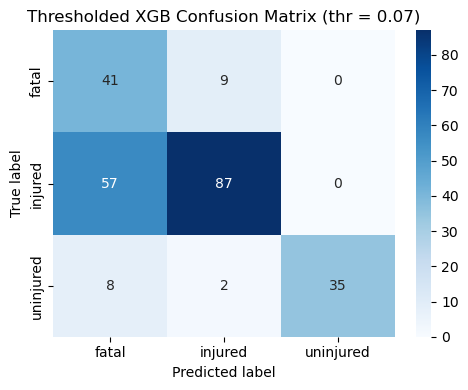

In [85]:
# Confusion matrix
cm = confusion_matrix(y_val, y_pred_thr, labels=classes)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=classes,
    yticklabels=classes
)

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title(f"Thresholded XGB Confusion Matrix (thr = {threshold})")
plt.tight_layout()
plt.show()


In [68]:
#----------CHECKING FEATURE : wether year is significant for fatal or non fatal (P value resulted in 0, finding out what causes this)
df_check = data1.copy()

year_class_counts = (
    df_check
    .groupby("Incident.year")["Victim.injury"]
    .value_counts()
    .unstack(fill_value=0)
)

year_class_counts.head(10)

Victim.injury,fatal,injured,uninjured
Incident.year,,,
1791,1,0,0
1803,0,1,0
1807,0,1,0
1820,1,0,0
1825,0,1,0
1830,0,1,0
1832,0,2,0
1836,2,1,0
1837,1,0,0


<Axes: xlabel='Incident.year'>

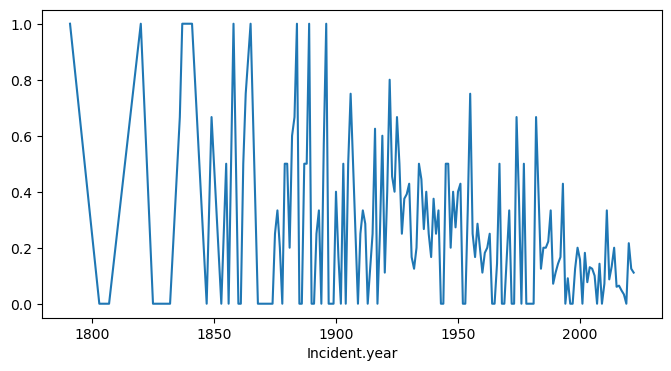

In [69]:
df_clean["fatal_bin"] = (df_clean["Victim.injury"].astype(str).str.lower().str.strip() == "fatal").astype(int)

fatal_rate_by_year = (
    df_clean
    .groupby("Incident.year")["fatal_bin"]
    .mean()
)
fatal_rate_by_year.plot(figsize=(8,4))

In [70]:
df_check.groupby("Victim.injury")["Incident.year"].describe()

,count,mean,std,min,25%,50%,75%,max
Victim.injury,,,,,,,,
fatal,250.0,1942.704000,48.980370,1791.0,1916.0,1936.5,1984.75,2022.0
injured,723.0,1969.663900,47.372095,1803.0,1934.0,1987.0,2011.00,2022.0
uninjured,223.0,1985.040359,39.158412,1855.0,1961.5,2002.0,2015.00,2022.0


fatal
0    946
1    250
Name: count, dtype: int64

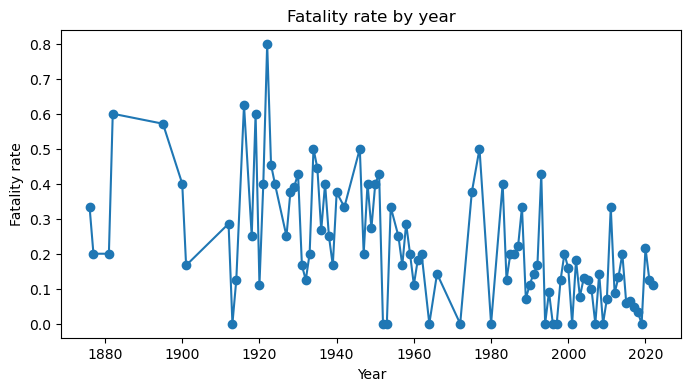

In [71]:
#-------CHECKING if Victim.injury is clean text-----------------------------
inj = df_check["Victim.injury"].astype(str).str.lower().str.strip()

# 1 if fatal else 0
df_check["fatal"] = (inj == "fatal").astype(int)

# Group by year using the numeric column
year_stats = (
    df_check.groupby("Incident.year")["fatal"]
    .agg(rate="mean", n="size")
)

# keep years with at least 5 incidents (optional)
year_stats = year_stats[year_stats["n"] >= 5]

# plot
ax = year_stats["rate"].plot(figsize=(8,4), marker="o")
ax.set_title("Fatality rate by year")
ax.set_xlabel("Year")
ax.set_ylabel("Fatality rate")

df_check[["Victim.injury", "fatal"]].head(10)
df_check["fatal"].value_counts(dropna=False)

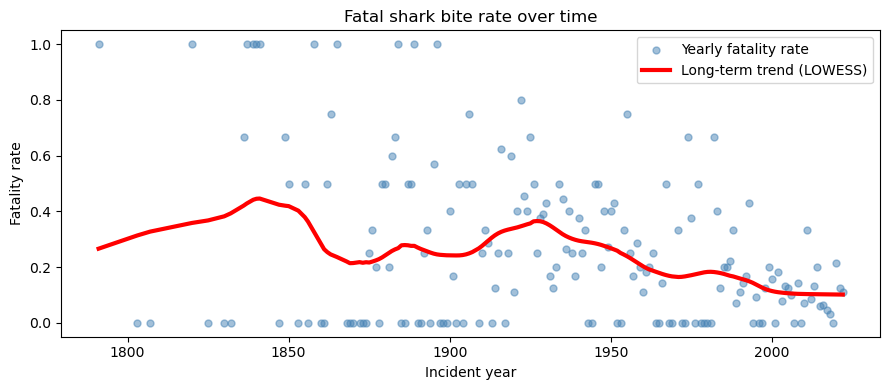

In [72]:
#---------------------------------------------Fatal Shark Bite Plot----------------------------------------
x = fatal_rate_by_year.index.values
y = fatal_rate_by_year.values

# LOWESS smoothing (very smooth)
smooth = lowess(y, x, frac=0.2)

plt.figure(figsize=(9,4))

# Raw yearly points (light + subtle)
plt.scatter(
    x, y,
    color="steelblue",
    alpha=0.5,
    s=25,
    label="Yearly fatality rate"
)

# Smooth trend line
plt.plot(
    smooth[:, 0],
    smooth[:, 1],
    color="red",
    linewidth=3,
    label="Long-term trend (LOWESS)"
)

plt.xlabel("Incident year")
plt.ylabel("Fatality rate")
plt.title("Fatal shark bite rate over time")
plt.legend()
plt.tight_layout()
plt.show()




In [73]:
#-----------------------------------------KRUSKAL WALLIS TO SEE IF YEAR IS SIGNIFICANT--------------------------------
groups = [
    df_check.loc[df_check["Victim.injury"] == "fatal", "Incident.year"],
    df_check.loc[df_check["Victim.injury"] == "injured", "Incident.year"],
    df_check.loc[df_check["Victim.injury"] == "uninjured", "Incident.year"],
]

H, p_value = kruskal(*groups)

print("Kruskal–Wallis H:", H)
print("p-value:", p_value)



Kruskal–Wallis H: 92.91425453226698
p-value: 6.666931350958112e-21


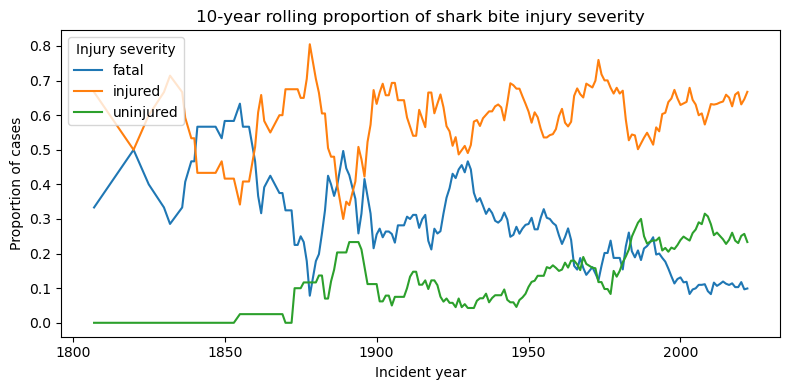

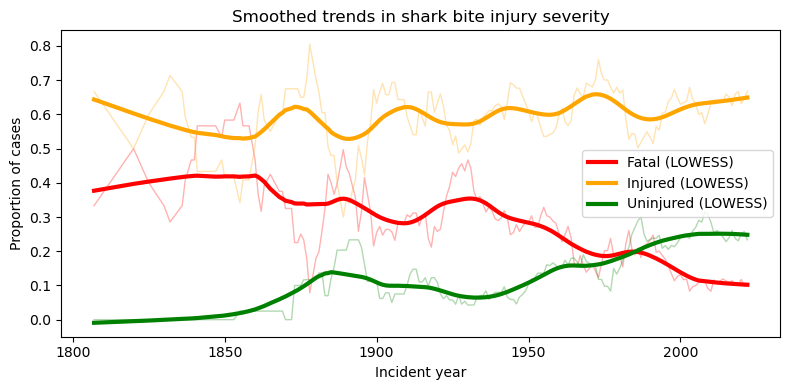

In [74]:
#------------------------------------PLOTS of SHARK BITES OVER THE YEARS-------------------------------------
counts = (
    df_check
    .groupby(["Incident.year", "Victim.injury"])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)

# Convert to proportions
proportions = counts.div(counts.sum(axis=1), axis=0)

# Rolling mean (10-year window)
rolling_props = proportions.rolling(window=10, min_periods=3).mean()

# Plot
rolling_props.plot(figsize=(8,4))
plt.xlabel("Incident year")
plt.ylabel("Proportion of cases")
plt.title("10-year rolling proportion of shark bite injury severity")
plt.legend(title="Injury severity")
plt.tight_layout()
plt.show()

#ADDING LOWES FOR SMOTH LINES
x = rolling_props.index.values

fatal_y = rolling_props["fatal"].values
injured_y = rolling_props["injured"].values
uninjured_y = rolling_props["uninjured"].values

mask_fatal = ~pd.isna(fatal_y)
mask_injured = ~pd.isna(injured_y)
mask_uninjured = ~pd.isna(uninjured_y)

fatal_smooth = lowess(
    fatal_y[mask_fatal],
    x[mask_fatal],
    frac=0.2
)

injured_smooth = lowess(
    injured_y[mask_injured],
    x[mask_injured],
    frac=0.2
)

uninjured_smooth = lowess(
    uninjured_y[mask_uninjured],
    x[mask_uninjured],
    frac=0.2
)

plt.figure(figsize=(8,4))

# Original rolling proportions (thin)
plt.plot(x, fatal_y, color="red", alpha=0.3, linewidth=1)
plt.plot(x, injured_y, color="orange", alpha=0.3, linewidth=1)
plt.plot(x, uninjured_y, color="green", alpha=0.3, linewidth=1)

# VERY smooth lines (thick)
plt.plot(
    fatal_smooth[:, 0],
    fatal_smooth[:, 1],
    color="red",
    linewidth=3,
    label="Fatal (LOWESS)"
)

plt.plot(
    injured_smooth[:, 0],
    injured_smooth[:, 1],
    color="orange",
    linewidth=3,
    label="Injured (LOWESS)"
)


plt.plot(
    uninjured_smooth[:, 0],
    uninjured_smooth[:, 1],
    color="green",
    linewidth=3,
    label="Uninjured (LOWESS)"
)

plt.xlabel("Incident year")
plt.ylabel("Proportion of cases")
plt.title("Smoothed trends in shark bite injury severity")
plt.legend()
plt.tight_layout()
plt.show()





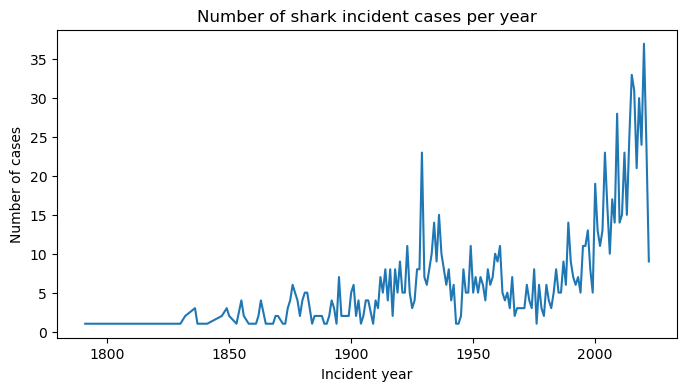

In [75]:
cases_per_year = (
    df_check
    .groupby("Incident.year")["Victim.injury"]
    .size()
)

plt.figure(figsize=(8,4))
plt.plot(cases_per_year.index, cases_per_year.values)
plt.xlabel("Incident year")
plt.ylabel("Number of cases")
plt.title("Number of shark incident cases per year")
plt.show()


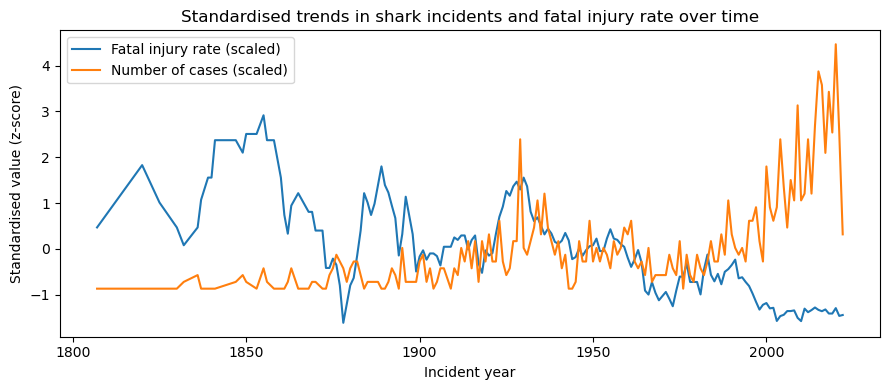

In [76]:
#combined graph
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import pandas as pd
from statsmodels.nonparametric.smoothers_lowess import lowess


# Prepare series
fatal_rate = fatal_rate_by_year.rolling(window=10, min_periods=3).mean()
cases = cases_per_year

# Align years (important!)
df_plot = pd.concat([fatal_rate, cases], axis=1)
df_plot.columns = ["fatal_rate", "cases"]
df_plot = df_plot.dropna()

# Scale
scaler = StandardScaler()
scaled = scaler.fit_transform(df_plot)

df_scaled = pd.DataFrame(
    scaled,
    index=df_plot.index,
    columns=["Fatal injury rate (scaled)", "Number of cases (scaled)"]
)

# Plot
plt.figure(figsize=(9,4))
plt.plot(df_scaled.index, df_scaled["Fatal injury rate (scaled)"], label="Fatal injury rate (scaled)")
plt.plot(df_scaled.index, df_scaled["Number of cases (scaled)"], label="Number of cases (scaled)")

plt.xlabel("Incident year")
plt.ylabel("Standardised value (z-score)")
plt.title("Standardised trends in shark incidents and fatal injury rate over time")
plt.legend()
plt.tight_layout()
plt.show()

fatal_trend = lowess(
    df_scaled["Fatal injury rate (scaled)"].values,
    df_scaled.index,
    frac=0.6   # VERY smooth
)

cases_trend = lowess(
    df_scaled["Number of cases (scaled)"].values,
    df_scaled.index,
    frac=0.6
)


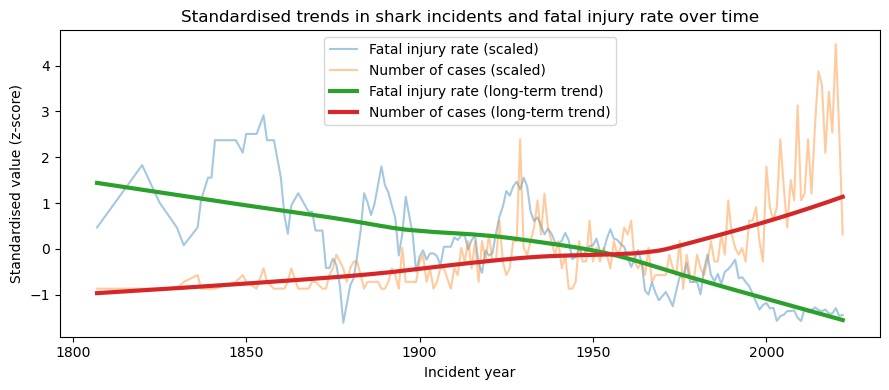

In [77]:
#-------------------------------FINAL PLOT------------------------------------------------------------
plt.figure(figsize=(9,4))
plt.plot(
    df_scaled.index,
    df_scaled["Fatal injury rate (scaled)"],
    alpha=0.4,
    label="Fatal injury rate (scaled)"
)

plt.plot(
    df_scaled.index,
    df_scaled["Number of cases (scaled)"],
    alpha=0.4,
    label="Number of cases (scaled)"
)

# EXTRA smooth trend lines (thicker)
plt.plot(
    fatal_trend[:,0],
    fatal_trend[:,1],
    linewidth=3,
    label="Fatal injury rate (long-term trend)"
)

plt.plot(
    cases_trend[:,0],
    cases_trend[:,1],
    linewidth=3,
    label="Number of cases (long-term trend)"
)

plt.xlabel("Incident year")
plt.ylabel("Standardised value (z-score)")
plt.title("Standardised trends in shark incidents and fatal injury rate over time")
plt.legend()
plt.tight_layout()
plt.show()

